# TransNested — Interactive Analysis

Set the configuration in the cell below, run everything after it, and get the
same diagnostic plots every time: evidence convergence, model-order posterior,
a corner plot of the recovered pulses, and the comparison against plain
RJ-MCMC.

No `.npz` file is ever touched directly in this notebook. The archive that
`TransNestedSampler.run()` writes is read only inside `plotting.py`, which
hands back finished figures.

This notebook calls the SAME code as the terminal / `nohup` entry point
(`analysis.py`) and the black-box interface (`transnested.py`). Nothing here
is a second copy of the sampler, the likelihood, or the priors — only the
settings and the plotting differ.

In [1]:
# SECTION 1 - IMPORTS

from transnested import TransNestedSampler
from pulse_model import generate_synthetic_dataset, build_time_axis

from plotting import (
    plot_diagnostics,
    plot_posterior,
    plot_corner,
    plot_rjmcmc_comparison,
)

## Section 2 — Settings

Everything you would normally reconfigure between runs lives in this one
cell. Re-run this cell and every cell after it to try new settings; nothing
above this point ever needs to change.

In [2]:
# SECTION 2 - SETTINGS

# [TUNABLE] The injected ("true") pulses, one [amplitude, mean_position] pair
#   each. Any length is valid, including a single pulse or an empty list for
#   pure noise. Every value must lie inside the prior bounds set below.
injected_pulses = [
    [2.0, -0.6],
    [2.0, -0.2],
    [2.0, +0.2],
    [2.0, +0.6],
]

# [TUNABLE] Standard deviation of the white Gaussian measurement noise.
#   Small (0.1-0.5) : high SNR, an easy recovery.
#   Large (1.0-2.0) : low SNR, where evidence-based model selection earns its
#                     keep and where the sampler is most worth stress-testing.
noise_sigma = 1.0

# [TUNABLE] Fixed Gaussian width shared by every pulse.
pulse_width = 0.1

# [TUNABLE] Observation window and resolution of the time axis.
number_of_time_samples = 500
time_axis_lower_bound = -1.0
time_axis_upper_bound = +1.0

# [TUNABLE] Random seed. Fixes the noise realisation AND every random draw in
#   the samplers, so the same settings always reproduce the same run.
seed = 0

# [TUNABLE] Nested Sampler settings.
#   n_live is the main accuracy/speed dial: try 50 for a quick look, 200 for
#   a result worth quoting. max_pulses must exceed len(injected_pulses).
n_live = 100
max_pulses = 8
amplitude_range = (0.0, 5.0)

# [TUNABLE] Whether to also run the plain RJ-MCMC baseline, and its settings.
#   Roughly doubles the runtime. Leave rjmcmc_temperatures at 10 -- at a
#   single temperature the baseline is known to mix badly on this problem.
compare_with_rjmcmc = True
rjmcmc_walkers = 50
rjmcmc_temperatures = 10
rjmcmc_steps = 20000

# [DERIVED] Where the archive is written. Change only if running several
#   configurations in the same session and you want to keep each archive.
save_to = "transnested_result.npz"

## Section 3 — Build the data and run

Data generation goes through `pulse_model.generate_synthetic_dataset`, the
same function `experiment.py` itself would use for a simulated dataset — not
a second copy written here. The run itself goes through `TransNestedSampler`,
exactly as it would from a terminal script.

In [3]:
# SECTION 3 - BUILD THE DATA AND RUN

time_axis = build_time_axis(
    number_of_time_samples, time_axis_lower_bound, time_axis_upper_bound)

dataset = generate_synthetic_dataset(
    time_axis, injected_pulses, noise_sigma, pulse_width, random_seed=seed)

print(f"Optimal matched-filter SNR of this injection: {dataset['snr']:.2f}")

sampler = TransNestedSampler(
    dataset["observed_data"],
    noise_sigma=noise_sigma,
    time=time_axis,
    pulse_width=pulse_width,
    max_pulses=max_pulses,
    amplitude_range=amplitude_range,
    n_live=n_live,
    seed=seed,
)

# Recorded so plotting.py and TransNestedResult can overlay the true answer.
# This is the same pattern TransNestedSampler.demo() itself uses internally.
sampler._injected_pulses = injected_pulses

result = sampler.run(
    compare_with_rjmcmc=compare_with_rjmcmc,
    rjmcmc_walkers=rjmcmc_walkers,
    rjmcmc_temperatures=rjmcmc_temperatures,
    rjmcmc_steps=rjmcmc_steps,
    save_to=save_to,
)

Optimal matched-filter SNR of this injection: 26.96
Analysing 500 samples, noise sigma = 1.0, considering up to 8 pulses, with RJ-MCMC comparison (50 walkers x 10 temperatures x 20,000 steps)...


Nested Sampling:   0%|          | 0/20000 [00:00<?, ?it/s]/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/ensemble.py:1273: UserWarning: All points input for the Likelihood have a log prior of -inf.
  warnings.warn(
Nested Sampling:   0%|          | 3/20000 [00:00<16:24, 20.31it/s]/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/moves/move.py:515: RuntimeWarning: invalid value encountered in multiply
  temp_change_log_like = new_log_likes * (accepted_temp) + old_log_likes * (
/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/moves/rj.py:330: RuntimeWarning: invalid value encountered in subtract
  lnpdiff = factors + logP - prev_logP
/home/efkourso/miniconda3/envs/thesis_env/lib/python3.10/site-packages/eryn/moves/mh.py:168: RuntimeWarning: invalid value encountered in subtract
  lnpdiff = factors + logP - prev_logP
Nested Sampling:  17%|█▋        | 3480/20000 [02:52<13:38, 20.19it/s]


    loop finished after 3481 iterations (evidence convergence criterion satisfied)
Starting plain RJ-MCMC baseline...


100%|██████████| 20000/20000 [15:33<00:00, 21.42it/s]



TransNestedResult
  pulses found        : 4   (posterior mean 4.44 +/- 0.70)
  P(that many)        : 0.673
  log Z               : -270.65 +/- 0.48
  log B vs pure noise : 344.1   (decisive signal detection)
  converged           : True
  plain RJ-MCMC says  : 4  (agrees)
  true answer was     : 4   (correct)


## Section 4 — Summary

In [9]:
# SECTION 4 - SUMMARY

print(result)

if compare_with_rjmcmc:
    print()
    result.compare()

TransNestedResult
  pulses found        : 4   (posterior mean 4.44 +/- 0.70)
  P(that many)        : 0.673
  log Z               : -270.65 +/- 0.48
  log B vs pure noise : 344.1   (decisive signal detection)
  converged           : True
  plain RJ-MCMC says  : 4  (agrees)
  true answer was     : 4   (correct)

Nested Sampler vs plain RJ-MCMC
  ----------------------------------------------------
                                Nested     RJ-MCMC
  number of pulses                   4           4
  confidence in that             0.673       0.629
  ----------------------------------------------------
  true answer: 4   Nested correct,  RJ-MCMC correct
  The two methods AGREE on the number of pulses.
  Total variation distance between the two posteriors: 0.054 (0 = identical, 1 = no overlap)


## Section 5 — Run diagnostics

Evidence convergence, the likelihood climb, and the model order of the best
live point, all across Nested Sampling iterations. What to look for: the left
panel should flatten, the middle panel should climb to (or past) the dashed
line and level off, and the right panel should settle near the true k.

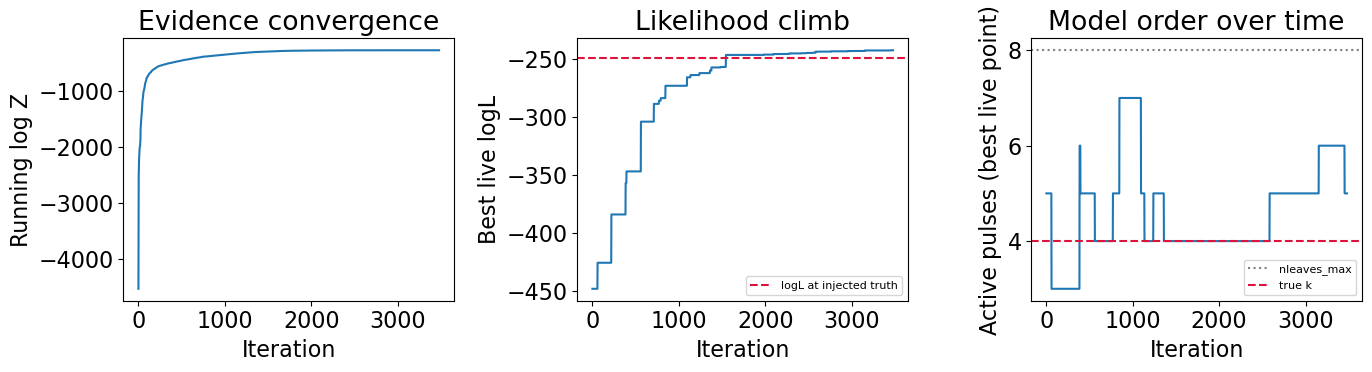

  k       NS       RJ     diff
  0   0.0000   0.0000  +0.0000
  1   0.0000   0.0000  +0.0000
  2   0.0000   0.0000  +0.0000
  3   0.0000   0.0000  +0.0000
  4   0.6733   0.6293  +0.0440
  5   0.2303   0.2823  -0.0519
  6   0.0834   0.0731  +0.0104
  7   0.0126   0.0136  -0.0010
  8   0.0003   0.0018  -0.0015


In [13]:
plot_diagnostics(result)

import numpy as np

ns = result.posterior_over_k
rj = result.rjmcmc_posterior_over_k

print(f"{'k':>3} {'NS':>8} {'RJ':>8} {'diff':>8}")
for k in range(len(ns)):
    rj_val = rj[k] if k < len(rj) else 0.0
    print(f"{k:>3} {ns[k]:>8.4f} {rj_val:>8.4f} {ns[k]-rj_val:>+8.4f}")

## Section 6 — Posterior on the number of pulses

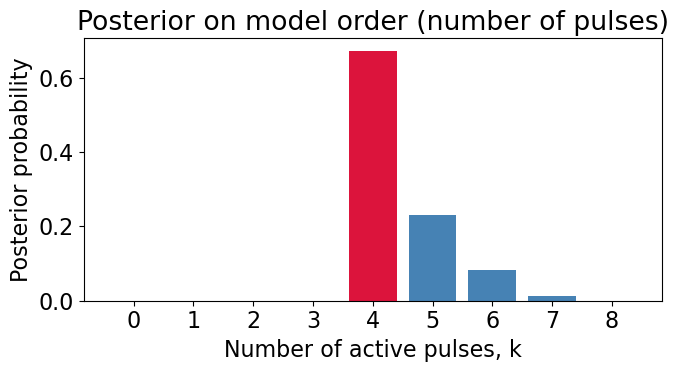

In [15]:
plot_posterior(result);

## Section 7 — Corner plot of the recovered pulses

Amplitude and mean position, pooled across every active leaf in the archive
and weighted by Nested Sampling weight. Red stars mark the injected truth.

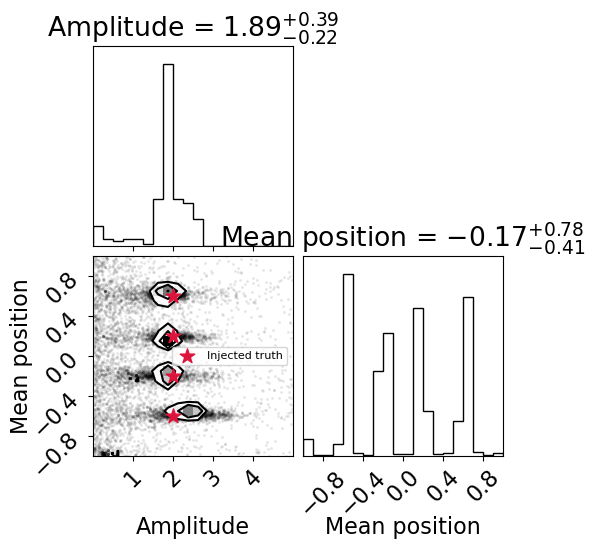

In [16]:
plot_corner(result);

## Section 8 — Comparison against plain RJ-MCMC

Only produces output if `compare_with_rjmcmc = True` in Section 2.

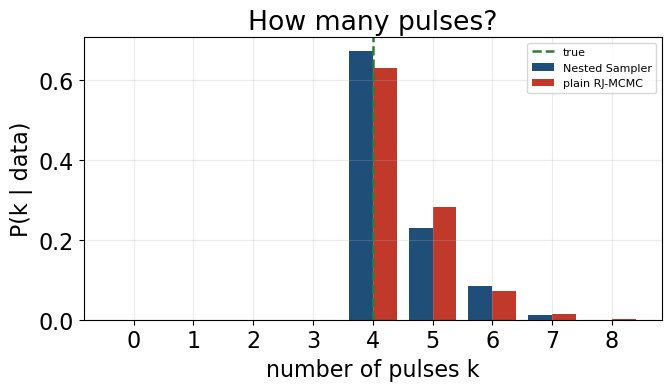

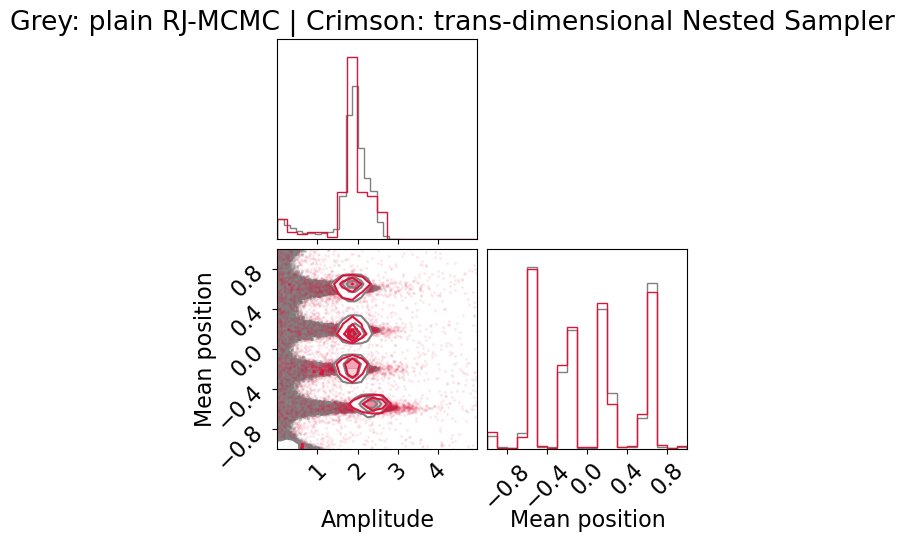

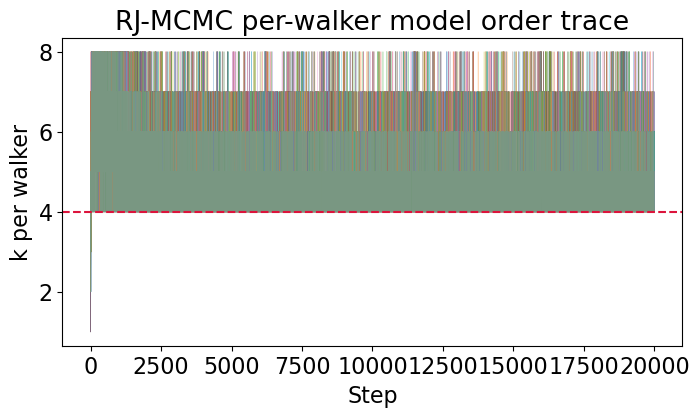

(<Figure size 700x420 with 1 Axes>,
 <Figure size 550x550 with 4 Axes>,
 <Figure size 800x400 with 1 Axes>)

In [8]:
plot_rjmcmc_comparison(result)